# Cyclistic Bike-Share Analysis
How do annual members and casual riders use Cyclistic (Divvy) bikes differently?

Analysis of 12 months of Divvy trip data (Jan–Dec 2021) to find behavioral differences between casual riders and annual members, and recommend ways to convert casual riders into members.

**Tools:** Python (Pandas, Matplotlib, Seaborn)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the full cleaned dataset
df = pd.read_csv("/Users/faribakazi/Downloads/PROJECTS/cyclistic-bike-share-analysis/csv/cyclistic_cleaned_full.csv")

print(f'Total rides: {len(df):,}')
print(f"Date range: {df['started_at'].min()} to {df['started_at'].max()}")

Total rides: 4,588,104
Date range: 2021-01-01 00:02:24 to 2021-12-31 23:59:48


In [2]:
# Key insights
print('Member vs Casual distribution:')
print(df['member_casual'].value_counts(normalize=True).round(4))

print('\nAverage ride length (minutes):')
print(df.groupby('member_casual')['ride_length'].mean().round(1))

print('\nMedian ride length (minutes):')
print(df.groupby('member_casual')['ride_length'].median().round(1))

Member vs Casual distribution:
member_casual
member    0.5536
casual    0.4464
Name: proportion, dtype: float64

Average ride length (minutes):
member_casual
casual    32.5
member    13.2
Name: ride_length, dtype: float64

Median ride length (minutes):
member_casual
casual    16.6
member     9.7
Name: ride_length, dtype: float64


In [3]:
# Clean labels for charts
df['rider_type'] = df['member_casual'].map({'member': 'Annual Member', 'casual': 'Casual Rider'})
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
palette = ['#1f77b4', '#ff7f0e']

/var/folders/js/6l0mnps15jj_30cyc_lhnlqc0000gn/T/ipykernel_13630/3243024237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rider_type', y='ride_length', data=df, errorbar=None, palette=palette)


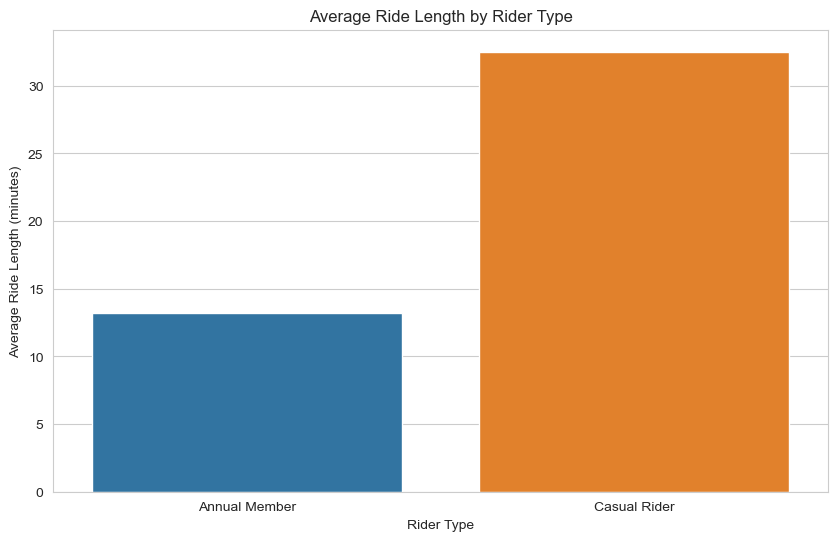

In [4]:
# 1. Average Ride Length by Rider Type
plt.figure()
sns.barplot(x='rider_type', y='ride_length', data=df, errorbar=None, palette=palette)
plt.title('Average Ride Length by Rider Type')
plt.xlabel('Rider Type'); plt.ylabel('Average Ride Length (minutes)')
plt.show()

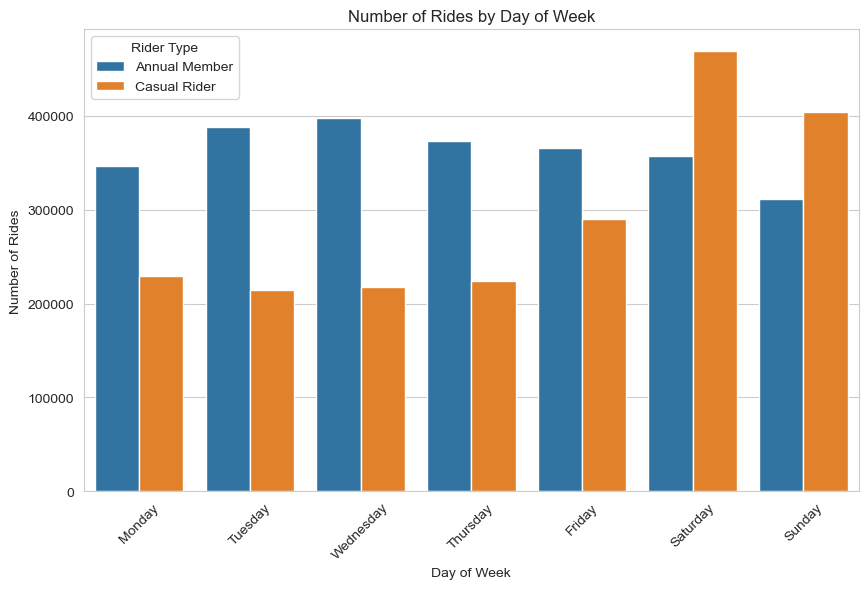

In [5]:
# 2. Number of Rides by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=day_order, ordered=True)
plt.figure()
sns.countplot(x='day_name', hue='rider_type', data=df, palette=palette)
plt.title('Number of Rides by Day of Week')
plt.xlabel('Day of Week'); plt.ylabel('Number of Rides')
plt.xticks(rotation=45); plt.legend(title='Rider Type')
plt.show()

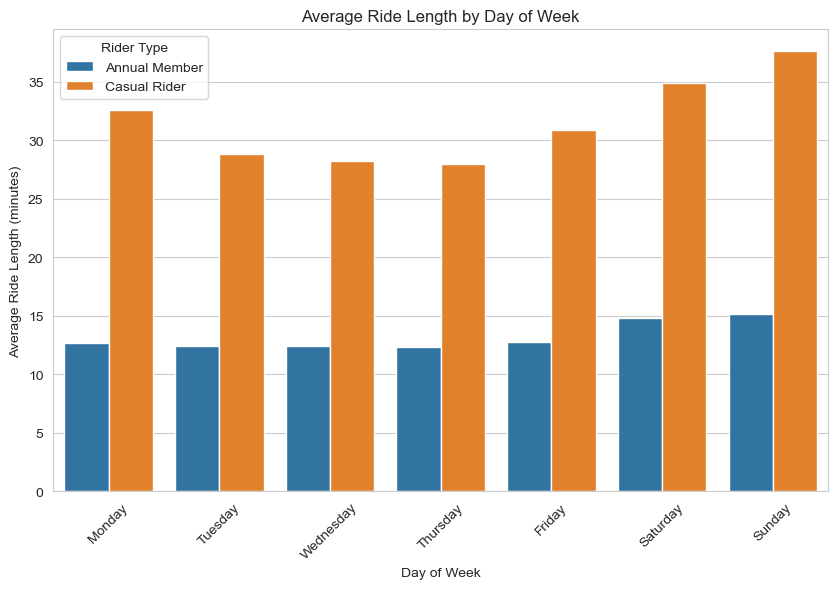

In [6]:
# 3. Average Ride Length by Day of Week
plt.figure()
sns.barplot(x='day_name', y='ride_length', hue='rider_type', data=df, errorbar=None, palette=palette)
plt.title('Average Ride Length by Day of Week')
plt.xlabel('Day of Week'); plt.ylabel('Average Ride Length (minutes)')
plt.xticks(rotation=45); plt.legend(title='Rider Type')
plt.show()

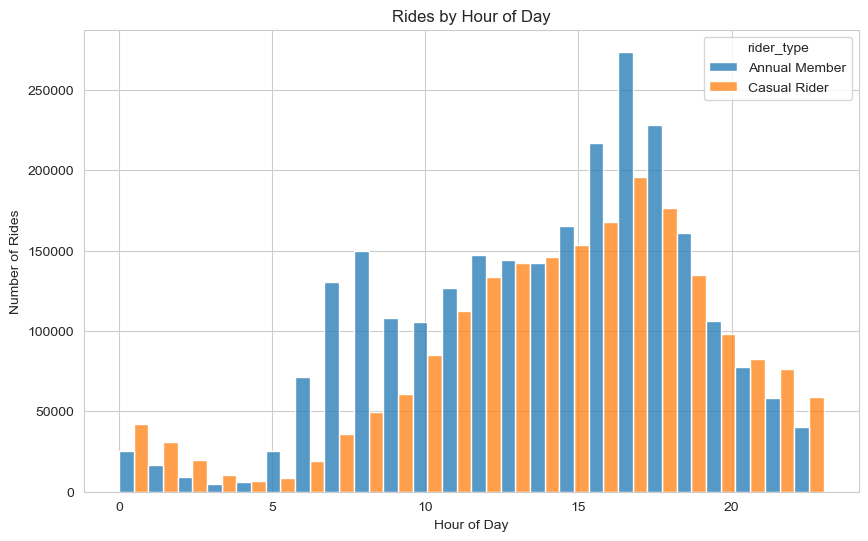

In [7]:
# 4. Rides by Hour of Day
plt.figure()
sns.histplot(data=df, x='hour_of_day', hue='rider_type', bins=24, multiple='dodge', palette=palette)
plt.title('Rides by Hour of Day')
plt.xlabel('Hour of Day'); plt.ylabel('Number of Rides')
plt.show()

## Key Findings
- Casual riders take much longer trips (32.5 min avg) than annual members (13.2 min)
- Casual riders ride mostly on weekends (leisure); members ride steadily on weekdays (commuting)
- Members show clear morning and late-afternoon commuter peaks

## Recommendations
1. Weekend-focused membership promotions for casual riders taking longer leisure rides
2. Position annual membership as the cost-effective choice for weekday commuters
3. Use targeted digital campaigns based on rider behavior patterns